# Practical 1: COMPAS Dataset Exploration

This notebook guides you through exploring the COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) dataset, originally analysed by ProPublica.

**Before you begin**, read the two ProPublica articles:
- [Machine Bias](https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing)
- [How We Analyzed the COMPAS Recidivism Algorithm](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm)


## Setup: Download the Dataset

Clone or download the dataset from GitHub:
```
git clone https://github.com/propublica/compas-analysis
```
The main file we will use is `compas-scores-two-years.csv`.

In [3]:
# Install any missing libraries if needed
#!pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Load the Data

Update `DATA_PATH` below to point to where you saved the dataset.

In [4]:
DATA_PATH = 'compas-analysis/compas-scores-two-years.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df_raw.shape}  ({df_raw.shape[0]} rows, {df_raw.shape[1]} columns)')
df_raw.head()

Dataset shape: (7214, 53)  (7214 rows, 53 columns)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,...,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.00,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.00,F,Aggravated Assault w/Firearm,0,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.00,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.00,F,Felony Battery w/Prior Convict,1,...,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.00,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.00,F,Possession of Cocaine,1,...,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.00,F,Possession of Cannabis,0,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.00,F,arrest case no charge,0,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [6]:
# Column names and data types
df_raw.dtypes

id                           int64
name                           str
first                          str
last                           str
compas_screening_date          str
sex                            str
dob                            str
age                          int64
age_cat                        str
race                           str
juv_fel_count                int64
decile_score                 int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_jail_in                      str
c_jail_out                     str
c_case_number                  str
c_offense_date                 str
c_arrest_date                  str
c_days_from_compas         float64
c_charge_degree                str
c_charge_desc                  str
is_recid                     int64
r_case_number                  str
r_charge_degree                str
r_days_from_arrest         float64
r_offense_date      

## 2.	Have a look at the dataset. 
- Does it need any cleaning? Do you find any null, unrelated or missed data? 
- How should missing data be handled? Does it makes sense to drop rows, impute, or leave as-is? Justify the choice you think you would make.
- What categorical data is included, do the demographic categories vary across datasets? 
- Can you think of data that might be useful but that is not included?


In [7]:
# Calculate summary statistics for all columns
df_raw.describe(include='all')

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,...,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
count,7214.00,7214,7214,7214,7214,7214,7214,7214.00,7214,7214,7214.00,7214.00,7214.00,7214.00,7214.00,6907.00,6907,6907,7192,6055,1137,7192.00,7214,7185,7214.00,...,3471,3413,2316,2316,0.00,7214.00,819,819,819,819,7214,7214.00,7214,7214,7214,7214.00,7214,7214,6978,6978,7214.00,7214.00,7214.00,7214.00,7214.00
unique,NaN,7158,2800,3950,690,2,5452,NaN,3,6,NaN,NaN,NaN,NaN,NaN,NaN,6907,6880,7192,927,580,NaN,2,437,NaN,...,1075,340,972,938,NaN,NaN,819,9,570,83,1,NaN,3,690,1,NaN,3,690,1156,1169,NaN,NaN,NaN,NaN,NaN
top,NaN,anthony smith,michael,williams,2013-02-20,Male,1989-04-27,NaN,25 - 45,African-American,NaN,NaN,NaN,NaN,NaN,NaN,2013-08-13 06:03:42,2013-09-28 02:10:00,13011352CF10A,2013-02-22,2013-02-06,NaN,F,Battery,NaN,...,2014-12-08,Driving License Suspended,2014-05-27,2014-12-09,NaN,NaN,13009779CF10A,(M1),2015-08-15,Battery,Risk of Recidivism,NaN,Low,2013-02-20,Risk of Violence,NaN,Low,2013-02-20,2014-01-22,2020-01-01,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,149,83,32,5819,5,NaN,4109,3696,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,26,9,NaN,4666,1156,NaN,...,12,258,9,9,NaN,NaN,1,344,6,329,7214,NaN,3897,32,7214,NaN,4761,32,20,61,NaN,NaN,NaN,NaN,NaN
mean,5501.26,NaN,NaN,NaN,NaN,NaN,NaN,34.82,NaN,NaN,0.07,4.51,0.09,0.11,3.47,3.30,NaN,NaN,NaN,NaN,NaN,57.73,NaN,NaN,0.48,...,NaN,NaN,NaN,NaN,NaN,0.11,NaN,NaN,NaN,NaN,NaN,4.51,NaN,NaN,NaN,3.69,NaN,NaN,NaN,NaN,3.47,11.47,553.44,0.38,0.45
std,3175.71,NaN,NaN,NaN,NaN,NaN,NaN,11.89,NaN,NaN,0.47,2.86,0.49,0.50,4.88,75.81,NaN,NaN,NaN,NaN,NaN,329.74,NaN,NaN,0.50,...,NaN,NaN,NaN,NaN,NaN,0.32,NaN,NaN,NaN,NaN,NaN,2.86,NaN,NaN,NaN,2.51,NaN,NaN,NaN,NaN,4.88,46.95,399.02,0.49,0.50
min,1.00,NaN,NaN,NaN,NaN,NaN,NaN,18.00,NaN,NaN,0.00,1.00,0.00,0.00,0.00,-414.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00
25%,2735.25,NaN,NaN,NaN,NaN,NaN,NaN,25.00,NaN,NaN,0.00,2.00,0.00,0.00,0.00,-1.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,0.00,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,2.00,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,0.00,0.00,148.25,0.00,0.00
50%,5509.50,NaN,NaN,NaN,NaN,NaN,NaN,31.00,NaN,NaN,0.00,4.00,0.00,0.00,2.00,-1.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,0.00,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,3.00,NaN,NaN,NaN,NaN,2.00,0.00,530.50,0.00,0.00
75%,8246.50,NaN,NaN,NaN,NaN,NaN,NaN,42.00,NaN,NaN,0.00,7.00,0.00,0.00,5.00,0.00,NaN,NaN,NaN,NaN,NaN,2.00,NaN,NaN,1.00,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,7.00,NaN,NaN,NaN,5.00,NaN,NaN,NaN,NaN,5.00,1.00,914.00,1.00,1.00


In [5]:
# Add your exploratory data analysis code here
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   str    
 2   first                    7214 non-null   str    
 3   last                     7214 non-null   str    
 4   compas_screening_date    7214 non-null   str    
 5   sex                      7214 non-null   str    
 6   dob                      7214 non-null   str    
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   str    
 9   race                     7214 non-null   str    
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count             7214 non-n

In [16]:
df = df_raw.copy()

missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_%': missing_pct
}).sort_values(by='missing_%', ascending=False)

missing_df

,missing_count,missing_%
violent_recid,7214,100.00
vr_charge_degree,6395,88.65
vr_offense_date,6395,88.65
vr_case_number,6395,88.65
vr_charge_desc,6395,88.65
c_arrest_date,6077,84.24
r_jail_in,4898,67.90
r_days_from_arrest,4898,67.90
r_jail_out,4898,67.90
r_charge_desc,3801,52.69


In [21]:
# these rows are missing too much data to be useful
df = df.drop(columns=[
    'violent_recid',
    'c_arrest_date',
], 
    errors='ignore')
# duplicated columns
df = df.drop(columns=[
    'decile_score.1', 
    'priors_count.1'
],
    errors='ignore')

In [22]:
df.describe()

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,is_violent_recid,v_decile_score,start,end,event,two_year_recid
count,7214.00,7214.00,7214.00,7214.00,7214.00,7214.00,7214.00,6907.00,7192.00,7214.00,2316.00,7214.00,7214.00,7214.00,7214.00,7214.00,7214.00
mean,5501.26,34.82,0.07,4.51,0.09,0.11,3.47,3.30,57.73,0.48,20.27,0.11,3.69,11.47,553.44,0.38,0.45
std,3175.71,11.89,0.47,2.86,0.49,0.50,4.88,75.81,329.74,0.50,74.87,0.32,2.51,46.95,399.02,0.49,0.50
min,1.00,18.00,0.00,1.00,0.00,0.00,0.00,-414.00,0.00,0.00,-1.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,2735.25,25.00,0.00,2.00,0.00,0.00,0.00,-1.00,1.00,0.00,0.00,0.00,1.00,0.00,148.25,0.00,0.00
50%,5509.50,31.00,0.00,4.00,0.00,0.00,2.00,-1.00,1.00,0.00,0.00,0.00,3.00,0.00,530.50,0.00,0.00
75%,8246.50,42.00,0.00,7.00,0.00,0.00,5.00,0.00,2.00,1.00,1.00,0.00,5.00,1.00,914.00,1.00,1.00
max,11001.00,96.00,20.00,10.00,13.00,17.00,38.00,1057.00,9485.00,1.00,993.00,1.00,10.00,937.00,1186.00,1.00,1.00


## 3. Explore by subgroup

Split the dataset into different demographic groups (i.e. gender, ethnicity, etc.). 

For demographic subgroups, explore the following:
- compute the size of the groups, 
- the average value for each (numeric) feature, 
- the variance of each (numeric) feature, 

**Questions** 
- How large is each demographic group? Are the groups balanced? What implications might imbalance have?

- Do you observe any interesting differences between the different subgroups‘ statistics?

In [25]:
# add your code here
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('id', errors='ignore')  # optional

def subgroup_analysis(df, group_col):
    print(f"\n===== Analysis by {group_col} =====\n")
    
    # Group sizes
    group_sizes = df[group_col].value_counts()
    print("Group sizes:")
    print(group_sizes)
    
    print("\nProportions:")
    print(df[group_col].value_counts(normalize=True))
    
    # Mean
    group_means = df.groupby(group_col)[numeric_cols].mean()
    print("\nMean values:")
    print(group_means)
    
    # Variance
    group_variance = df.groupby(group_col)[numeric_cols].var()
    print("\nVariance:")
    print(group_variance)
    
    return group_sizes, group_means, group_variance


===== Analysis by sex =====

Group sizes:
sex
Male      5819
Female    1395
Name: count, dtype: int64

Proportions:
sex
Male     0.81
Female   0.19
Name: proportion, dtype: float64

Mean values:
         age  juv_fel_count  decile_score  juv_misd_count  juv_other_count  \
sex                                                                          
Female 34.90           0.01          4.17            0.04             0.05   
Male   34.80           0.08          4.59            0.10             0.12   

        priors_count  days_b_screening_arrest  c_days_from_compas  is_recid  \
sex                                                                           
Female          2.28                     2.03               58.52      0.38   
Male            3.76                     3.61               57.54      0.51   

        r_days_from_arrest  is_violent_recid  v_decile_score  start    end  \
sex                                                                          
Female            

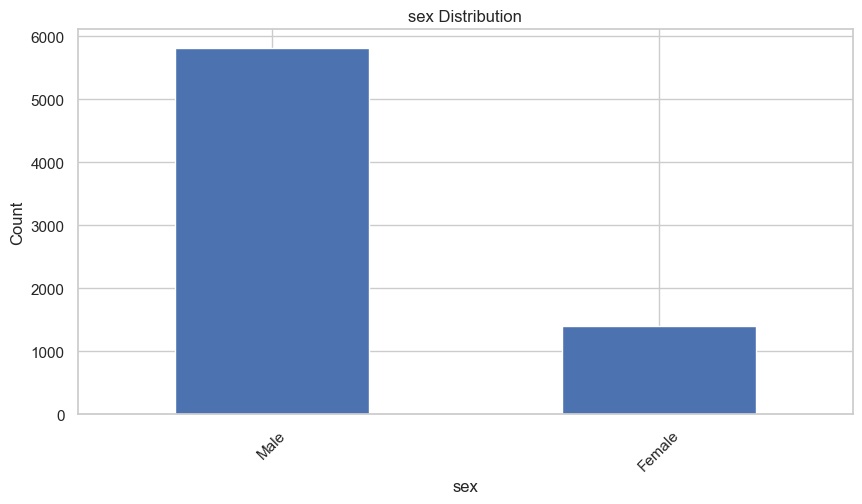

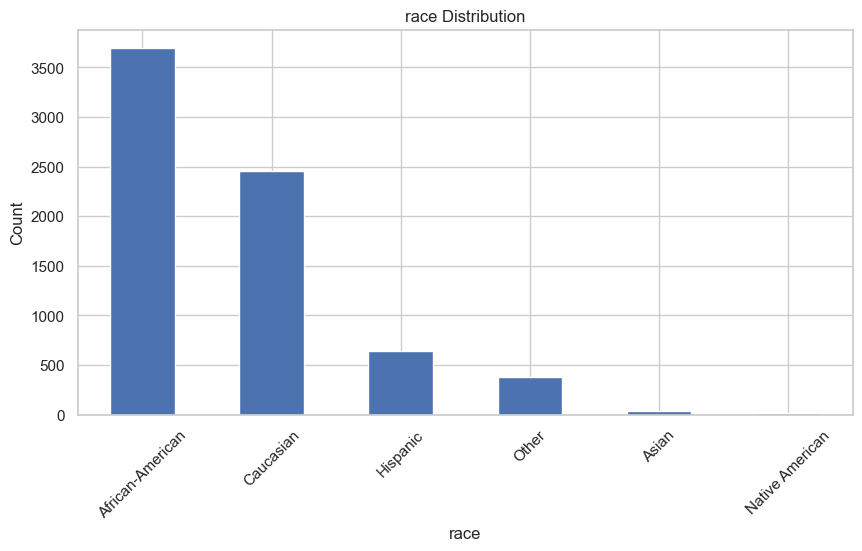

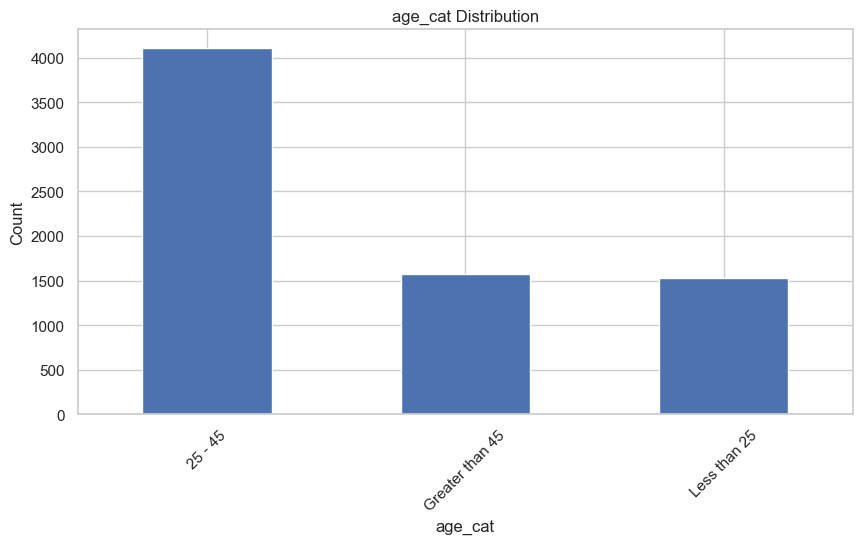

<Figure size 1000x500 with 0 Axes>

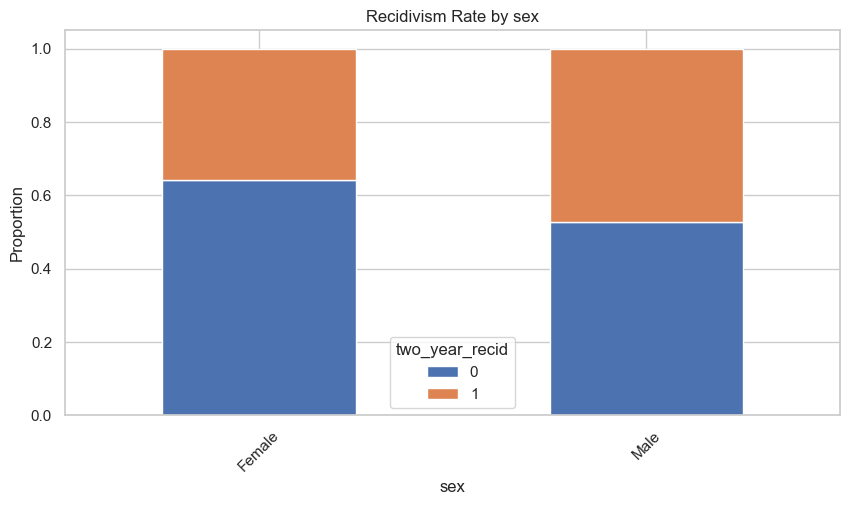

<Figure size 1000x500 with 0 Axes>

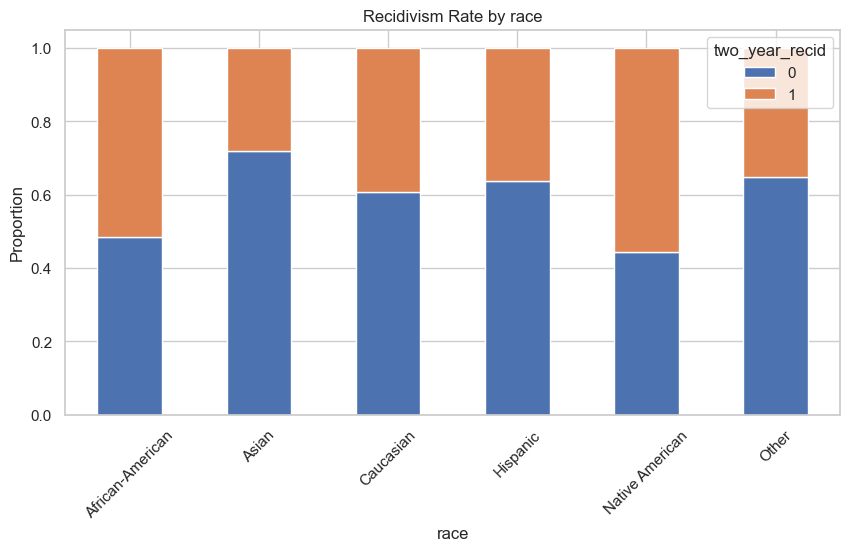

<Figure size 1000x500 with 0 Axes>

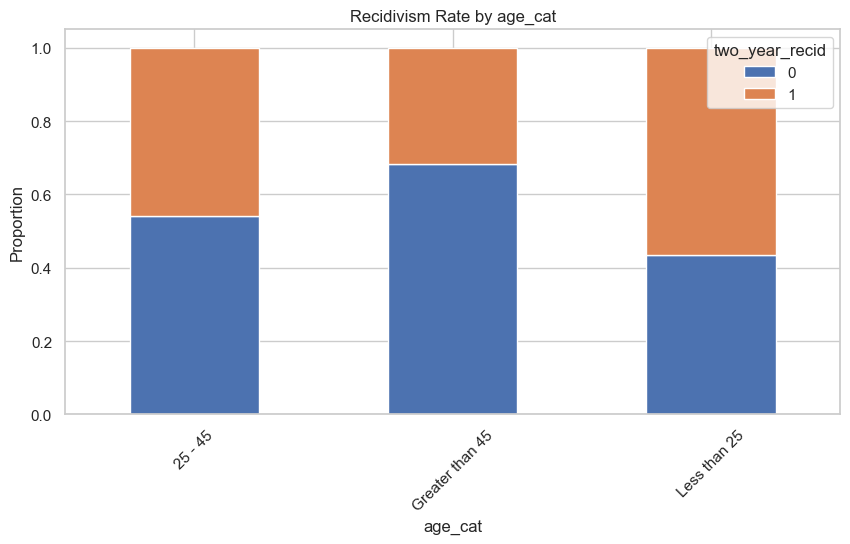

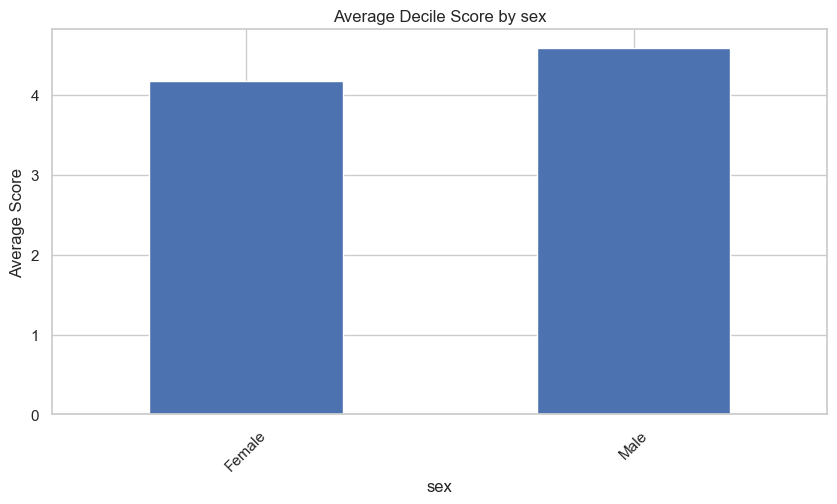

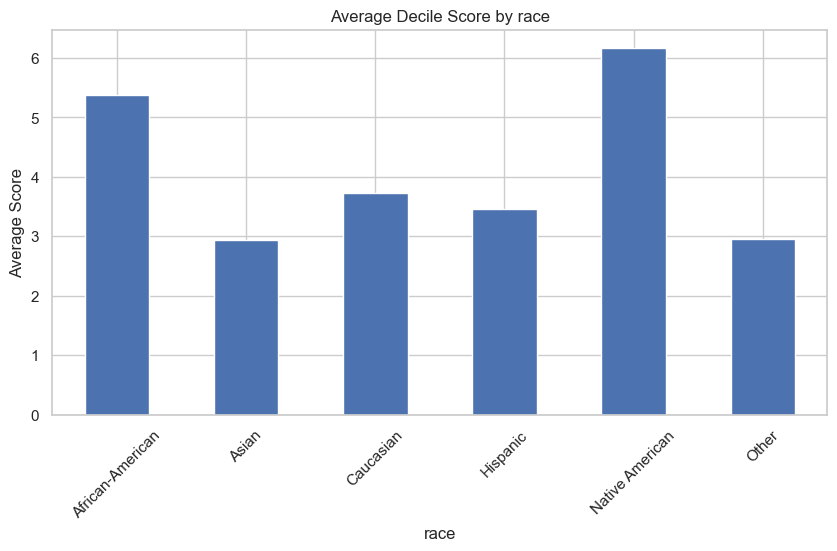

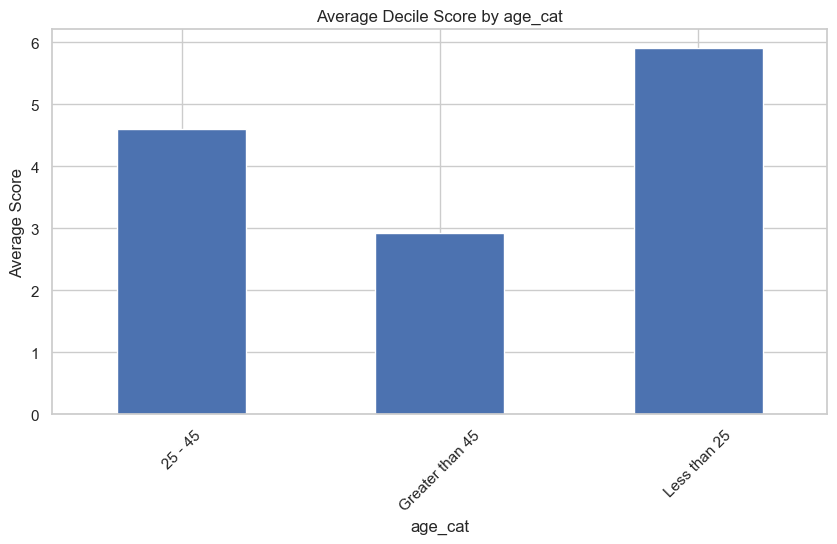

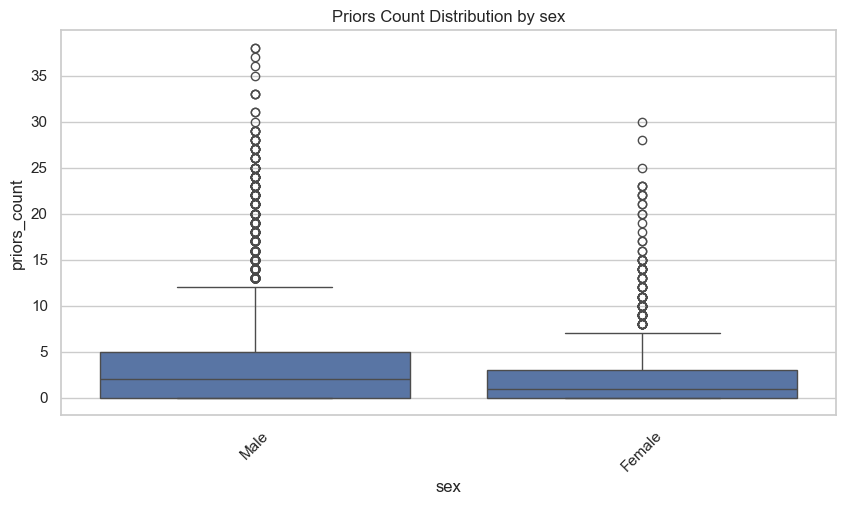

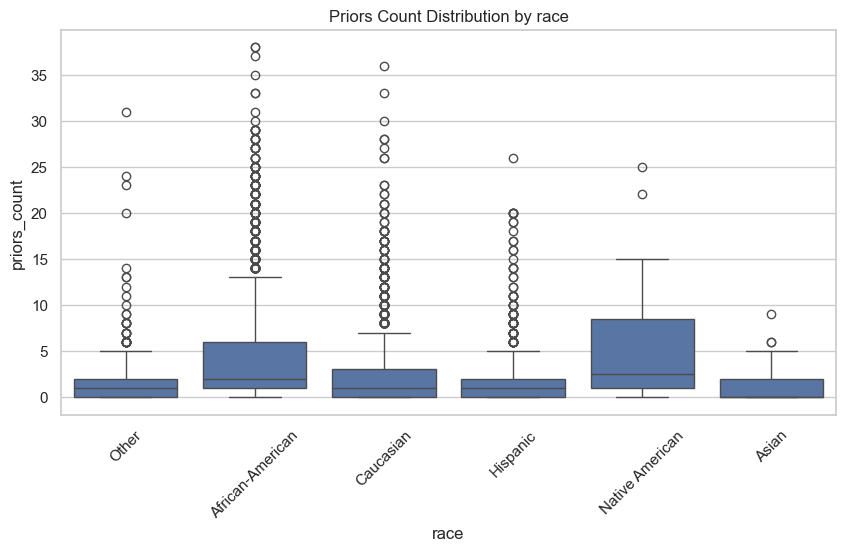

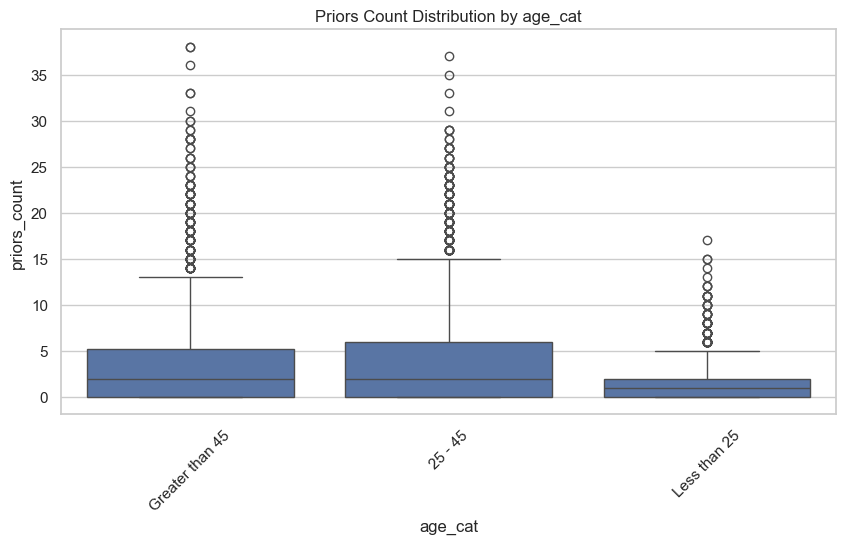

In [26]:

demographic_cols = ['sex', 'race', 'age_cat']
results = {}

for col in demographic_cols:
    sizes, means, var = subgroup_analysis(df, col)
    results[col] = {
        'sizes': sizes,
        'means': means,
        'var': var
    }

# -------------------------------
# VISUALISATIONS
# -------------------------------

# 1. Group size distributions
for col in demographic_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


# 2. Recidivism rate by group
for col in demographic_cols:
    plt.figure()
    recid_rate = pd.crosstab(df[col], df['two_year_recid'], normalize='index')
    recid_rate.plot(kind='bar', stacked=True)
    plt.title(f'Recidivism Rate by {col}')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='two_year_recid')
    plt.show()


# 3. Average COMPAS score by group
for col in demographic_cols:
    plt.figure()
    df.groupby(col)['decile_score'].mean().plot(kind='bar')
    plt.title(f'Average Decile Score by {col}')
    plt.ylabel('Average Score')
    plt.xticks(rotation=45)
    plt.show()


# 4. Priors count distribution by group (boxplot)
for col in demographic_cols:
    plt.figure()
    sns.boxplot(x=col, y='priors_count', data=df)
    plt.title(f'Priors Count Distribution by {col}')
    plt.xticks(rotation=45)
    plt.show()

## 4. Analysis & visualise

You can follow the code from this blog post: http://blog.kennylee.info/projects/python/data/machinelearning/bias/2020/11/01/analyze-Compas.html 

To: 

- Replicate the ProPublica's Filtering 
- Calculate the distribution of decile scores and visualise the results
- Conduct a logistic regression analysis 

---
## 5. Go further 

If you have time, now that you are famlliar with the dataset you can explore some of the specific measures we discussed in teh lecture, e.g. comparing **false positive rates** (labelled high-risk but did NOT reoffend) and **false negative rates** (labelled low-risk but DID reoffend) across racial, gender or other groups. 

Resources and tutorials: 
- You can see the original ProPpublica analysis here: https://github.com/propublica/compas-analysis/blob/master/Compas%20Analysis.ipynb 

- This tutorial walks through it nicely: https://colab.research.google.com/github/AllenDowney/RecidivismCaseStudy/blob/v1/01_classification.ipynb#scrollTo=_xajeYIMjoRm

- This tutorial looks at the calibration measure that Northpoint used in thier defence: https://colab.research.google.com/github/AllenDowney/RecidivismCaseStudy/blob/v1/02_calibration.ipynb#scrollTo=d96CNRWTh0Mo


---
## Extension: Further exploration ideas

If you finish early, try one or more of the following:
- **Train a simple model** to predict recidivism using the available features, and compare its fairness properties to COMPAS.

- **Repeat the analysis using the `compas-scores-two-years-violent.csv`** dataset (violent recidivism). Do the patterns hold?

- **Explore intersectionality**: split the data by *both* race and sex simultaneously. Does the picture change?

- **Read the Northpointe response** to the ProPublica article and consider who you find most convincing.


---
Discussion Questions

Use your findings from the analysis above to discuss the following questions with your group. You can write your notes in the cells below.

### Q1. What bias did you observe?

Describe any patterns or disparities you noticed. Which groups were affected and in what direction?

*Your answer here...*

### Q2. Why might this bias have occurred?

Consider the data collection process, historical context, and what features are used in the score.

*Your answer here...*

### Q3. Who are the affected people, and how are their perspectives represented?

Think about defendants, victims, communities, and the criminal justice system.

*Your answer here...*

### Q4. What definition of fairness was used, and what are the alternatives?

Consider: equal accuracy, equal false positive rates, equal false negative rates, calibration. Can all of these be satisfied simultaneously?

*Your answer here...*

### Q5. Can different stakeholder perspectives be reconciled?

Citizens who want public safety, defendants who don't want to be falsely imprisoned, law enforcement, and policymakers may all define fairness differently.

*Your answer here...*